# Session 7 Step 2: Full-Scale Evaluation Suite

Three production runs at 20k iters on the full v1.2 train partition
(41 cases / 138 train encounters per D35). The notebook evaluates each
on Test A (in-sample held-out encounters), Test B (parametric interpolation
to unseen (G, D, Y), THE PRIMARY METRIC), and Test C (extrapolation to
|G|=4). Produces the complete metric table + decision string per the
8-branch tree in SESSION7_FULL_SCALE_HONEST.md Step 2 Section 6.

Three runs:
- **R1: PLDM + OBS + BN** (`--gpu 0`). D39 smoke winner, scaled up.
- **R2: PLDM only, eta=0, BN** (`--gpu 1`). OBS-vs-no-OBS control.
- **R3: SIGReg + OBS + BN** (`--gpu 1` after R2). Regulariser-asymmetry test.

The headline figure is `delta_test_b = r2(z -> CL_future) - r2((c, t) -> CL_future)`.
Positive delta means the latent encodes generalisable flow physics
beyond a case-frame lookup. Reported per-run; honest checkpoint discipline.


In [1]:
from __future__ import annotations

import json
import os
import sys
from collections import defaultdict
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml

REPO = Path.cwd().resolve()
while REPO.name and not (REPO / 'configs' / 'splits').exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
print('repo root:', REPO)

from src.models.encoder import HybridCNNViTEncoder
from src.training.diagnostics import linear_probe_r2, participation_ratio

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
D = 32

PREVENT = Path(os.environ.get('PREVENT_ROOT', '/home/carlos/PREVENT'))
CACHE = Path(os.environ.get('VORTEX_JEPA_CACHE', PREVENT / 'data' / 'processed' / 'vortex-jepa'))


repo root: /home/carlos/GUST-JEPA


device: cuda


## Section 1: Load the three Session 7 runs

In [2]:
RUN_SPECS = {
    'R1 PLDM+OBS+BN': (REPO / 'outputs' / 'runs' / 'session7' / 'run_r1_pldm_obs_bn',  20000, 'pldm'),
    'R2 PLDM only BN': (REPO / 'outputs' / 'runs' / 'session7' / 'run_r2_pldm_only_bn', 20000, 'pldm'),
    'R3 SIGReg+OBS+BN': (REPO / 'outputs' / 'runs' / 'session7' / 'run_r3_sigreg_obs_bn', 20000, 'jepa'),
}


def load_run(run_dir: Path, iters: int, kind: str):
    ckpt = run_dir / f'checkpoint_iter{iters:06d}.pt'
    blob = torch.load(ckpt, map_location='cpu', weights_only=False)
    args = blob['args']
    enc = HybridCNNViTEncoder(
        latent_dim=int(args['d']),
        projection_norm=args.get('projection_norm', 'batchnorm'),
    )
    state_key = 'wrapper_state_dict' if kind == 'pldm' else 'jepa_state_dict'
    state = {k.removeprefix('encoder.'): v for k, v in blob[state_key].items()
             if k.startswith('encoder.')}
    enc.load_state_dict(state, strict=False)
    enc.eval().to(device)
    rows = []
    with open(run_dir / 'metrics.jsonl') as f:
        for line in f:
            evt = json.loads(line)
            if evt.get('event') == 'log':
                rows.append(evt)
    df = pd.DataFrame(rows).set_index('step') if rows else pd.DataFrame()
    return enc, args, df


loaded = {}
for label, (run_dir, iters, kind) in RUN_SPECS.items():
    ckpt = run_dir / f'checkpoint_iter{iters:06d}.pt'
    if not ckpt.exists():
        print(f'  MISSING: {label} ({ckpt})')
        continue
    enc, args, df = load_run(run_dir, iters, kind)
    loaded[label] = (enc, args, df, kind)
    print(f'  {label:25s}  kind={kind}  iters={iters}  '
          f'all_train={args.get("all_train", False)}  '
          f'obs={args.get("observable_head", "none")}')
print(f'loaded {len(loaded)} runs')


  R1 PLDM+OBS+BN             kind=pldm  iters=20000  all_train=True  obs=cl_future


  R2 PLDM only BN            kind=pldm  iters=20000  all_train=True  obs=none


  R3 SIGReg+OBS+BN           kind=jepa  iters=20000  all_train=True  obs=cl_future
loaded 3 runs


## Section 2: Encode every encounter in Test A, Test B, Test C

In [3]:
def gather_encounters(split_key: str) -> list[dict]:
    """Load every encounter in the requested split from cache.

    split_key: 'test_a' for held-out encounters within train cases;
               'test_b' for the 6 interior interpolation cases;
               'test_c' for the 4 |G|=4 extrapolation cases.
    """
    with open(REPO / 'configs' / 'splits' / 'split_v1.json') as f:
        manifest = json.load(f)
    encs = []
    for cid, case in manifest['cases'].items():
        if split_key == 'test_a' and case['split'] == 'train':
            ks = case['test_a_encounter_indices']
        elif split_key == 'test_b' and case['split'] == 'test_b':
            ks = list(range(case['n_encounters_full']))
        elif split_key == 'test_c' and case['split'] == 'test_c':
            ks = list(range(case['n_encounters_full']))
        else:
            continue
        for k in ks:
            path = CACHE / 'v1' / cid / f'encounter_{k:02d}.h5'
            with h5py.File(path, 'r') as g:
                encs.append({
                    'case_id': cid, 'k': int(k),
                    'omega_z': np.asarray(g['omega_z'], dtype=np.float32),
                    'C_L': np.asarray(g['C_L'], dtype=np.float32),
                    'G': float(g.attrs['G']),
                    'D': float(g.attrs['D']),
                    'Y': float(g.attrs['Y']),
                })
    return encs


SPLITS = {}
for split in ('test_a', 'test_b', 'test_c'):
    SPLITS[split] = gather_encounters(split)
    print(f'  {split}: {len(SPLITS[split])} encounters, '
          f'{len(set(e["case_id"] for e in SPLITS[split]))} cases')


def encode_split(enc: HybridCNNViTEncoder, encs: list[dict]) -> np.ndarray:
    N = len(encs)
    T = encs[0]['omega_z'].shape[0]
    out = np.empty((N, T, D), dtype=np.float32)
    with torch.no_grad():
        for i, e in enumerate(encs):
            x = torch.from_numpy(e['omega_z']).unsqueeze(1).to(device)
            with torch.autocast(device_type=device.type, dtype=torch.bfloat16, enabled=device.type == 'cuda'):
                z = enc(x.unsqueeze(0))
            out[i] = z.squeeze(0).float().cpu().numpy()
    return out


encoded = {label: {} for label in loaded}
for label, (enc, _, _, _) in loaded.items():
    for split in ('test_a', 'test_b', 'test_c'):
        encoded[label][split] = encode_split(enc, SPLITS[split])
        print(f'  {label} {split}: z shape={encoded[label][split].shape}  finite={np.isfinite(encoded[label][split]).all()}')


  test_a: 56 encounters, 41 cases


  test_b: 28 encounters, 6 cases


  test_c: 24 encounters, 4 cases


  R1 PLDM+OBS+BN test_a: z shape=(56, 120, 32)  finite=True


  R1 PLDM+OBS+BN test_b: z shape=(28, 120, 32)  finite=True


...

  R2 PLDM only BN test_b: z shape=(28, 120, 32)  finite=True


  R2 PLDM only BN test_c: z shape=(24, 120, 32)  finite=True


  R3 SIGReg+OBS+BN test_a: z shape=(56, 120, 32)  finite=True


  R3 SIGReg+OBS+BN test_b: z shape=(28, 120, 32)  finite=True


  R3 SIGReg+OBS+BN test_c: z shape=(24, 120, 32)  finite=True


## Section 3: Static/dynamic decomposition + (c, t) baseline per split

In [4]:
DELTAS = (8, 16, 24)


def build_cl_future(encs):
    N = len(encs); T = encs[0]['omega_z'].shape[0]
    out = np.empty((N, T, len(DELTAS)), dtype=np.float32)
    for i, e in enumerate(encs):
        cl_full = e['C_L']
        for j, d in enumerate(DELTAS):
            for t in range(T):
                src = t + d
                out[i, t, j] = cl_full[src] if src < cl_full.shape[0] else cl_full[-1]
    return out


# Two run3 D=1.5 encounters in Test A have NaN in their CL series (DNS
# instability near the last encounter). Drop those encounters from CL
# computations but keep them for the PR/probe metrics on z (which use
# omega and c only). Same filter applied to Test B / Test C even though
# they were finite at session start; future cache regenerations could
# reintroduce NaNs in any split.
CL_FUTURE_RAW = {split: build_cl_future(SPLITS[split]) for split in SPLITS}
CL_VALID_MASK = {}
for split, cl in CL_FUTURE_RAW.items():
    per_enc_finite = np.isfinite(cl).reshape(cl.shape[0], -1).all(axis=1)
    CL_VALID_MASK[split] = per_enc_finite
    n_kept = int(per_enc_finite.sum())
    print(f'  cl_future {split}: shape={cl.shape}  kept {n_kept}/{cl.shape[0]} encounters '
          f'(dropped {cl.shape[0] - n_kept} for NaN/Inf)')
    if cl.shape[0] - n_kept > 0:
        for i, ok in enumerate(per_enc_finite):
            if not ok:
                e = SPLITS[split][i]
                print(f'    dropped: {e["case_id"]} enc {e["k"]} (G={e["G"]:+.2f}, D={e["D"]:.2f}, Y={e["Y"]:+.2f})')


def _cl_finite(split):
    mask = CL_VALID_MASK[split]
    return CL_FUTURE_RAW[split][mask]


def _encs_finite(split):
    mask = CL_VALID_MASK[split]
    return [e for e, ok in zip(SPLITS[split], mask) if ok]


# Build CL_FUTURE as the FILTERED version for downstream MLP fits
CL_FUTURE = {split: _cl_finite(split) for split in SPLITS}


def case_of(encs):
    return np.array([e['case_id'] for e in encs])


def c_of(encs):
    return np.stack([[e['G'], e['D'], e['Y']] for e in encs], axis=0).astype(np.float32)


def split_static_dynamic(z_all, case_arr):
    cases = sorted(set(case_arr))
    means = np.stack([z_all[case_arr == cid].reshape(-1, D).mean(axis=0) for cid in cases])
    cid_to_idx = {cid: i for i, cid in enumerate(cases)}
    z_dyn = z_all.copy()
    for i in range(z_all.shape[0]):
        z_dyn[i] -= means[cid_to_idx[case_arr[i]]]
    return means, z_dyn


def pr_of(arr_2d):
    return float(participation_ratio(torch.from_numpy(arr_2d.astype(np.float32))))


def probe(z, y, seed=0):
    n = z.shape[0]
    rng = np.random.default_rng(seed); perm = rng.permutation(n)
    nfit = max(2, int(0.75 * n)); fit, ev = perm[:nfit], perm[nfit:]
    r = linear_probe_r2(
        torch.from_numpy(z.astype(np.float32)), torch.from_numpy(y.astype(np.float32)),
        torch.from_numpy(fit), torch.from_numpy(ev),
    )
    return float(r['r2_overall']) if isinstance(r, dict) else float(r)


def fit_mlp(X, y, seed=0, hidden=64, epochs=400, lr=1e-2):
    torch.manual_seed(seed)
    n, in_dim = X.shape
    out_dim = y.shape[1]
    perm = torch.randperm(n, generator=torch.Generator().manual_seed(seed))
    fit, ev = perm[: int(0.75 * n)], perm[int(0.75 * n):]
    X_t = torch.from_numpy(X.astype(np.float32))
    y_t = torch.from_numpy(y.astype(np.float32))
    model = nn.Sequential(nn.Linear(in_dim, hidden), nn.GELU(), nn.Linear(hidden, out_dim))
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        model.train()
        p = model(X_t[fit])
        loss = F.mse_loss(p, y_t[fit])
        opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        p_ev = model(X_t[ev])
    ss_res = ((y_t[ev] - p_ev) ** 2).sum(dim=0)
    ss_tot = ((y_t[ev] - y_t[ev].mean(dim=0)) ** 2).sum(dim=0).clamp_min(1e-8)
    r2 = (1.0 - ss_res / ss_tot).mean().item()
    return float(r2)


def fit_mlp_oos(X_train, y_train, X_eval, y_eval, seed=0, hidden=64, epochs=400, lr=1e-2):
    """Train MLP on (X_train, y_train), evaluate r2 on a DIFFERENT (X_eval, y_eval)."""
    torch.manual_seed(seed)
    in_dim = X_train.shape[1]; out_dim = y_train.shape[1]
    X_tr = torch.from_numpy(X_train.astype(np.float32))
    y_tr = torch.from_numpy(y_train.astype(np.float32))
    X_ev = torch.from_numpy(X_eval.astype(np.float32))
    y_ev = torch.from_numpy(y_eval.astype(np.float32))
    model = nn.Sequential(nn.Linear(in_dim, hidden), nn.GELU(), nn.Linear(hidden, out_dim))
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        model.train()
        p = model(X_tr); loss = F.mse_loss(p, y_tr)
        opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        p_ev = model(X_ev)
    ss_res = ((y_ev - p_ev) ** 2).sum(dim=0)
    ss_tot = ((y_ev - y_ev.mean(dim=0)) ** 2).sum(dim=0).clamp_min(1e-8)
    return float((1.0 - ss_res / ss_tot).mean().item())


  cl_future test_a: shape=(56, 120, 3)  kept 54/56 encounters (dropped 2 for NaN/Inf)
    dropped: G+2.00_D1.50_Y+0.00 enc 3 (G=+2.00, D=1.50, Y=+0.00)
    dropped: G-2.00_D1.50_Y+0.10 enc 3 (G=-2.00, D=1.50, Y=+0.10)
  cl_future test_b: shape=(28, 120, 3)  kept 28/28 encounters (dropped 0 for NaN/Inf)
  cl_future test_c: shape=(24, 120, 3)  kept 24/24 encounters (dropped 0 for NaN/Inf)


## Section 4: per-split metric table (Test A, Test B, Test C)

For Test B / Test C: the latent r2(z -> CL_future) is computed by
training a tiny MLP on Test A latents (in-sample) and evaluating on
the held-out Test B / Test C latents. Same for the (c, t) baseline.

In [5]:
rows = []
for label, (enc, _, _, _) in loaded.items():
    z_a = encoded[label]['test_a']
    z_b = encoded[label]['test_b']
    z_c = encoded[label]['test_c']
    case_a = case_of(SPLITS['test_a'])
    case_b = case_of(SPLITS['test_b'])
    case_c = case_of(SPLITS['test_c'])
    c_a = c_of(SPLITS['test_a'])
    c_b = c_of(SPLITS['test_b'])
    c_c = c_of(SPLITS['test_c'])
    T = z_a.shape[1]

    # PR + linear probes on z: use the FULL split (no NaN filtering needed on z)
    cm_a, z_dyn_a = split_static_dynamic(z_a, case_a)
    pr_a = pr_of(z_a.reshape(-1, D))
    pr_w_a = float(np.mean([pr_of(z_dyn_a[case_a == cid].reshape(-1, D)) for cid in sorted(set(case_a))]))
    r2_zc_a = probe(z_a.reshape(-1, D), np.repeat(c_a, T, axis=0))
    r2_dphase_a = probe(z_dyn_a.reshape(-1, D), np.tile(np.arange(T, dtype=np.float32), z_a.shape[0])[:, None])

    # CL-prediction MLPs: filter to the CL-valid encounters (per the CL_VALID_MASK).
    mask_a = CL_VALID_MASK['test_a']
    z_a_cl = z_a[mask_a]; case_a_cl = case_a[mask_a]; c_a_cl = c_a[mask_a]
    cl_a = CL_FUTURE['test_a'].reshape(-1, 3)
    z_a_flat = z_a_cl.reshape(-1, D)
    ct_a_flat = np.hstack([np.repeat(c_a_cl, T, axis=0), np.tile(np.arange(T)[:, None], (z_a_cl.shape[0], 1)).astype(np.float32)])
    r2_cl_a = fit_mlp(z_a_flat, cl_a)
    r2_ct_a = fit_mlp(ct_a_flat, cl_a)

    for split_name, z_split, c_split in [('test_b', z_b, c_b), ('test_c', z_c, c_c)]:
        T_s = z_split.shape[1]
        case_split = case_of(SPLITS[split_name])
        # OOS probe: trained on the filtered Test A, evaluated on the filtered split
        mask_s = CL_VALID_MASK[split_name]
        z_s_cl = z_split[mask_s]; c_s_cl = c_split[mask_s]
        cl_s = CL_FUTURE[split_name].reshape(-1, 3)
        z_s_flat = z_s_cl.reshape(-1, D)
        ct_s_flat = np.hstack([np.repeat(c_s_cl, T_s, axis=0), np.tile(np.arange(T_s)[:, None], (z_s_cl.shape[0], 1)).astype(np.float32)])
        r2_cl_oos = fit_mlp_oos(z_a_flat, cl_a, z_s_flat, cl_s)
        r2_ct_oos = fit_mlp_oos(ct_a_flat, cl_a, ct_s_flat, cl_s)

        # PR + r2(z->c) computed on the FULL split (no need for CL filter)
        z_split_flat = z_split.reshape(-1, D)
        pr_all = pr_of(z_split_flat)
        cm_s, z_dyn_s = split_static_dynamic(z_split, case_split)
        pr_within = float(np.mean([
            pr_of(z_dyn_s[case_split == cid].reshape(-1, D))
            for cid in sorted(set(case_split))
        ]))
        r2_zc = probe(z_split_flat, np.repeat(c_split, T_s, axis=0))
        r2_dphase = probe(z_dyn_s.reshape(-1, D), np.tile(np.arange(T_s, dtype=np.float32), z_split.shape[0])[:, None])
        rows.append({
            'run': label, 'split': split_name,
            'PR_all': pr_all, 'PR_within': pr_within,
            'r2_z_c': r2_zc, 'r2_dyn_phase': r2_dphase,
            'r2_CL_future': r2_cl_oos, 'r2_ct_baseline': r2_ct_oos,
            'delta': r2_cl_oos - r2_ct_oos,
        })

    rows.append({
        'run': label, 'split': 'test_a',
        'PR_all': pr_a, 'PR_within': pr_w_a,
        'r2_z_c': r2_zc_a, 'r2_dyn_phase': r2_dphase_a,
        'r2_CL_future': r2_cl_a, 'r2_ct_baseline': r2_ct_a,
        'delta': r2_cl_a - r2_ct_a,
    })

df = pd.DataFrame(rows)
df = df.set_index(['run', 'split']).sort_index()
df.round(3)


PR_all  PR_within  r2_z_c  r2_dyn_phase  \
run              split                                             
R1 PLDM+OBS+BN   test_a  27.841      6.865   0.903         0.780   
                 test_b  18.308     10.063   0.956         0.907   
                 test_c  14.501     11.769   0.898         0.864   
R2 PLDM only BN  test_a  27.158      6.013   0.883         0.771   
                 test_b  17.352      9.411   0.951         0.922   
                 test_c  13.915     11.144   0.906         0.873   
R3 SIGReg+OBS+BN test_a   3.688      4.178   0.622         0.441   
                 test_b   3.506      3.854   0.931         0.625   
                 test_c   2.910      4.669   0.759         0.734   

                         r2_CL_future  r2_ct_baseline  delta  
run              split                                        
R1 PLDM+OBS+BN   test_a         0.969           0.738  0.230  
                 test_b         0.710           0.718 -0.008  
                 test_c         0.764           0.348  0.416  
R2 PLDM only BN  test_a         0.925           0.738  0.187  
                 test_b        -0.134           0.718 -0.852  
                 test_c         0.316           0.348 -0.031  
R3 SIGReg+OBS+BN test_a         0.974           0.738  0.236  
                 test_b         0.856           0.718  0.138  
                 test_c         0.829           0.348  0.481

## Section 5: training trajectory comparison

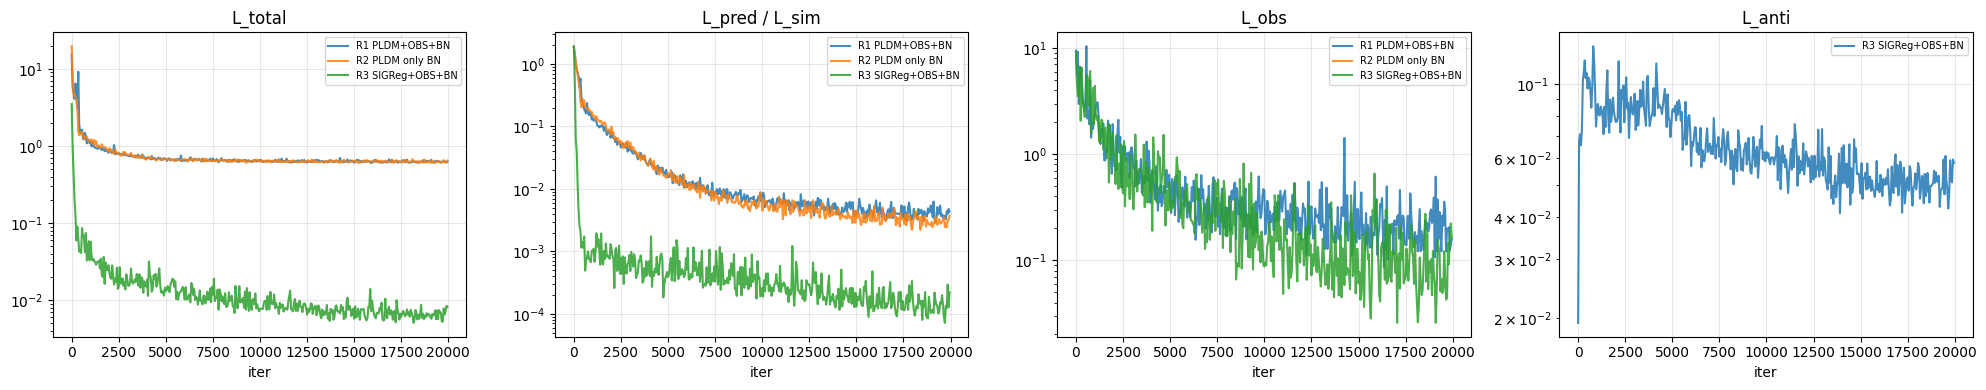

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True)
keys = ['loss_total', 'L_sim', 'L_obs', 'loss_anticollapse']
keys_jepa = ['loss_total', 'loss_pred', 'loss_obs', 'loss_anticollapse']
titles = ['L_total', 'L_pred / L_sim', 'L_obs', 'L_anti']
for ax, k_p, k_j, title in zip(axes, keys, keys_jepa, titles):
    for label, (_, _, dfm, kind) in loaded.items():
        key = k_p if kind == 'pldm' else k_j
        if key not in dfm.columns:
            continue
        sub = dfm[key].dropna()
        if sub.empty:
            continue
        ax.plot(sub.index, sub.values, label=label, alpha=0.85)
    ax.set_title(title); ax.set_yscale('log'); ax.set_xlabel('iter')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()


## Section 6: decision string (8-branch tree)

In [7]:
# Pull out delta_test_b per run; delta_test_a as the sanity check
delta_a = {lab: float(df.loc[(lab, 'test_a'), 'delta']) for lab in df.index.get_level_values(0).unique()}
delta_b = {lab: float(df.loc[(lab, 'test_b'), 'delta']) for lab in df.index.get_level_values(0).unique()}
delta_c = {lab: float(df.loc[(lab, 'test_c'), 'delta']) for lab in df.index.get_level_values(0).unique()}
pr_within_b = {lab: float(df.loc[(lab, 'test_b'), 'PR_within']) for lab in df.index.get_level_values(0).unique()}

R1 = 'R1 PLDM+OBS+BN'
R2 = 'R2 PLDM only BN'
R3 = 'R3 SIGReg+OBS+BN'

print(f'  delta_test_a: {delta_a}')
print(f'  delta_test_b: {delta_b}')
print(f'  delta_test_c: {delta_c}')
print(f'  PR_within(test_b): {pr_within_b}')

r1_b = delta_b.get(R1, float('-inf'))
r2_b = delta_b.get(R2, float('-inf'))
r3_b = delta_b.get(R3, float('-inf'))

decision = None
notes = []

# TEST_B_TEST_A_DISCREPANCY check (any run)
for lab in (R1, R2, R3):
    if delta_a.get(lab, 0) > 0.10 and delta_b.get(lab, 0) < 0.03:
        decision = 'TEST_B_TEST_A_DISCREPANCY'
        notes.append(f'{lab}: test_a delta {delta_a[lab]:.2f} >> test_b delta {delta_b[lab]:.2f}')
        break

# ALL_FAIL
if decision is None and r1_b < 0.03 and r2_b < 0.03 and r3_b < 0.03:
    decision = 'ALL_FAIL'

# R3_WINS
if decision is None and r3_b > r1_b:
    decision = 'R3_WINS'

# PLDM_ALONE_VIABLE: R2 essentially matches R1 on Test B
if decision is None and r2_b > r1_b - 0.02:
    decision = 'PLDM_ALONE_VIABLE'

# OBS_NECESSARY: R1 >> R2, AND R3 also positive
if decision is None and r1_b > r2_b + 0.05 and r3_b > 0:
    decision = 'OBS_NECESSARY'

# REGULARISER_ASYMMETRY: R1 >> R3
if decision is None and r1_b > r3_b + 0.05:
    decision = 'REGULARISER_ASYMMETRY'

# STRONG_GO vs WEAK_GO
if decision is None:
    if r1_b > 0.10 and pr_within_b.get(R1, 0) > 4:
        decision = 'STRONG_GO'
    elif r1_b > 0.03:
        decision = 'WEAK_GO'
    else:
        decision = 'ALL_FAIL'

print()
print(f'Session 7 outcome: {decision}')
for n in notes:
    print(f'  note: {n}')

followup = {
    'STRONG_GO':              'Session 8: lambda bisection on PLDM weights, eta sweep, decoder, paper finalisation (~6h)',
    'WEAK_GO':                'Session 8: STRONG_GO playbook + explicit Test C investigation; 40k iter extension on best run (~8h)',
    'PLDM_ALONE_VIABLE':      'Session 8: lambda bisection on R2 config (no OBS); paper simplifies (~8h)',
    'OBS_NECESSARY':          'Session 8: eta sweep on R1 AND R3 to test regulariser-independent OBS optimisability (~10h)',
    'REGULARISER_ASYMMETRY':  'Session 8: lambda bisection on R1 (PLDM+OBS); R3 documented as comparator (~6h)',
    'R3_WINS':                'Session 8: reframe around R3 (SIGReg+OBS); lambda bisection on SIGReg lambda (~8h)',
    'ALL_FAIL':               'Session 8: run R0 (pure SIGReg+BN full scale); paper reframes around diagnostic contribution (~10h)',
    'TEST_B_TEST_A_DISCREPANCY': 'Session 8: case-similarity analysis + regularisation strength variation (~10h)',
}[decision]
print(f'Session 8 implied: {followup}')


  delta_test_a: {'R1 PLDM+OBS+BN': 0.23036479949951172, 'R2 PLDM only BN': 0.18676996231079102, 'R3 SIGReg+OBS+BN': 0.23615646362304688}
  delta_test_b: {'R1 PLDM+OBS+BN': -0.008325338363647461, 'R2 PLDM only BN': -0.8523406386375427, 'R3 SIGReg+OBS+BN': 0.1379508376121521}
  delta_test_c: {'R1 PLDM+OBS+BN': 0.4159480035305023, 'R2 PLDM only BN': -0.03146812319755554, 'R3 SIGReg+OBS+BN': 0.4807835519313812}
  PR_within(test_b): {'R1 PLDM+OBS+BN': 10.063318093617758, 'R2 PLDM only BN': 9.411069313685099, 'R3 SIGReg+OBS+BN': 3.853602886199951}

Session 7 outcome: TEST_B_TEST_A_DISCREPANCY
  note: R1 PLDM+OBS+BN: test_a delta 0.23 >> test_b delta -0.01
Session 8 implied: Session 8: case-similarity analysis + regularisation strength variation (~10h)


## Section 7: per-test split sanity report

A bullet list of suspicious patterns to surface in the session report.

In [8]:
sanity = []
for lab in (R1, R2, R3):
    if lab not in df.index.get_level_values(0).unique():
        continue
    da = delta_a.get(lab, 0); db = delta_b.get(lab, 0); dc = delta_c.get(lab, 0)
    if da < 0:
        sanity.append(f'{lab}: Test A delta NEGATIVE ({da:.3f}) -- run is broken')
    if abs(db - da) > 0.2:
        sanity.append(f'{lab}: Test B delta {db:.3f} vs Test A delta {da:.3f} (gap {db - da:+.3f})')
    if dc > 0.05:
        sanity.append(f'{lab}: Test C delta POSITIVE ({dc:.3f}) -- extrapolation actually works')
    pr_a = df.loc[(lab, 'test_a'), 'PR_within']
    if pr_a < 2:
        sanity.append(f'{lab}: Test A PR_within {pr_a:.2f} below useful-dynamics threshold (=2)')

if not sanity:
    print('No sanity flags.')
else:
    for s in sanity:
        print(f'  - {s}')


  - R1 PLDM+OBS+BN: Test B delta -0.008 vs Test A delta 0.230 (gap -0.239)
  - R1 PLDM+OBS+BN: Test C delta POSITIVE (0.416) -- extrapolation actually works
  - R2 PLDM only BN: Test B delta -0.852 vs Test A delta 0.187 (gap -1.039)
  - R3 SIGReg+OBS+BN: Test C delta POSITIVE (0.481) -- extrapolation actually works
